/opt/conda/envs/km310gpu/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
INFO:purepyindi2.transports:Connected to localhost:7624


0.30066145520144316


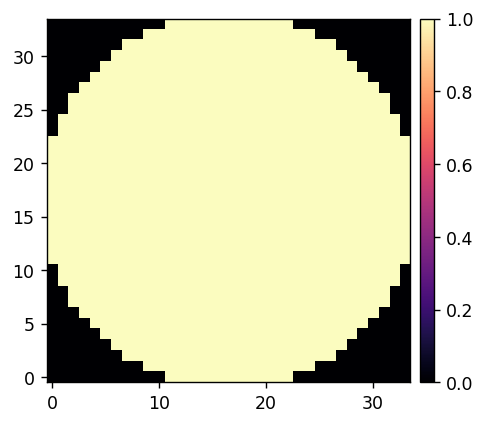

In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle, Rectangle

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import iefc, dm, utils, rt_utils, coro_utils, scoob_utils

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()

    client = IndiClient()
    client.connect()
    client.get_properties()

Nact = 34
ncamsci = 256
camsci_pxscl_lamDc = 1/3.326
print(camsci_pxscl_lamDc)

dm_mask = dm.create_mask(Nact=34)
utils.imshow([dm_mask])

# Make some plots


In [86]:
data_path = Path('/data/users/kianmilani/20260706')
iefc_data = utils.load_pickle(data_path/'iefc_results_90.pkl')
wfs_mask = iefc_data['wfs_mask']

ts_dirs = [
    'time-series-1',
    'time-series-2',
    'time-series-3',
]

ts_ims = []
ts_times = []
contrasts = []
for i in range(len(ts_dirs)):
    ts_path = data_path/ts_dirs[i]
    ts_fnames = utils.get_fnames(ts_path/'*.fits')

    short_ts_ims = []
    short_ts_contrasts = []
    short_ts_times = []
    for j in range(len(ts_fnames)):
        im = ensure_np_array(utils.load_fits(ts_fnames[j]))
        abs_time = float(ts_fnames[j][-22:-5])
        if i==0 and j==0: t0 = abs_time
        rel_time = abs_time - t0
        short_ts_times.append(rel_time)
        short_ts_ims.append(im)
        short_ts_contrasts.append(ensure_np_array(utils.mean(xp.array(im), wfs_mask)))

        # utils.save_fits(ts_fnames[j]+'.fits', im)

    ts_ims.append(short_ts_ims)
    ts_times.append(short_ts_times)
    contrasts.append(short_ts_contrasts)

# ts_ims = xp.array(ts_ims)

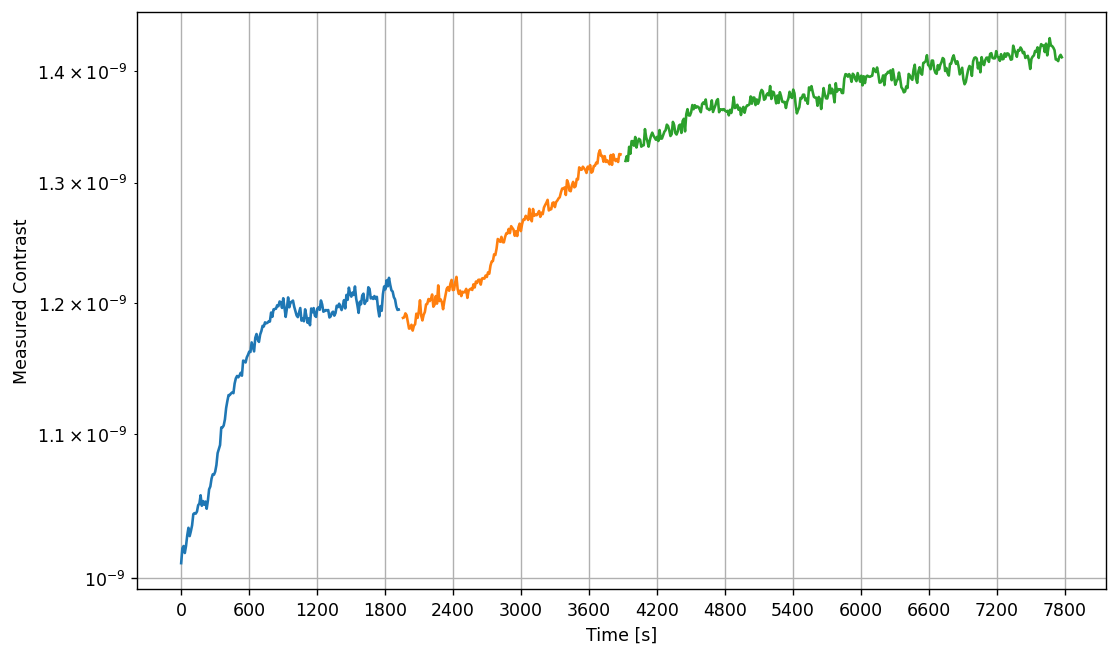

In [83]:

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(10,6), dpi=125)
for i in range(len(contrasts)):
    axs.semilogy(ts_times[i], contrasts[i], label=f'Dataset {i+1}')

axs.set_xlabel('Time [s]')
axs.set_ylabel('Measured Contrast')
axs.set_xticks(np.arange(0, 8400, 600))
axs.grid()


In [93]:
all_ims = np.concatenate(ts_ims, axis=0)
all_times = np.concatenate(ts_times)
all_contrasts = np.concatenate(contrasts)
all_ims.shape, all_times.shape, all_contrasts.shape

((720, 256, 256), (720,), (720,))

In [ ]:
import matplotlib
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.animation import FFMpegWriter, PillowWriter

def create_time_series_anim(
        camsci_ims,
        contrasts,
        times,
        numframes=None,
        cmap='magma',
        norm=None,
        pxscl=1,
        figsize=(5,5), 
        dpi=125, 
        interval=0.1, # in s
    ):
    numframes = camsci_ims.shape[0] if numframes is None else numframes
    print(numframes)

    # print(times)

    npix = camsci_ims[0].shape[0]
    
    i = 0
    camsci_im = camsci_ims[i]
    contrast = contrasts[i]
    rel_time = times[i]
    title = f'Time = {rel_time:.3f} s\nContrast = {contrast:.2e}'

    fig, axs = plt.subplots(
        nrows=1, ncols=1, 
        figsize=figsize, 
        dpi=dpi, 
    )

    extent = np.array([-npix/2, npix/2, -npix/2, npix/2]) * pxscl

    ax = axs
    im = ax.imshow(camsci_im, norm=norm, cmap=cmap, extent=extent)
    im_title = ax.set_title(title, fontsize=14,)
    # ax.set_xticks(np.arange(-30, 30.1, 10))
    # ax.set_yticks(np.arange(-30, 30.1, 10))
    ax.set_xlabel('X [$\lambda/D$]')
    ax.set_ylabel('Y [$\lambda/D$]')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.set_ylabel('NI', rotation=0, labelpad=25)

    def animate(i):
        camsci_im = ensure_np_array(camsci_ims[i])
        contrast = contrasts[i]
        rel_time = times[i]
        title = f'Time = {rel_time:.3f} s\nContrast = {contrast:.2e}'

        im_title.set_text(title)
        im.set_data(camsci_im)
        
        # im.set_clim([0, np.max(camlo_im)])
        
    anim = matplotlib.animation.FuncAnimation(fig, animate, frames=numframes, interval=interval*1000)
    return anim

In [117]:
all_contrasts[0]

np.float64(1.0099447142771615e-09)

720


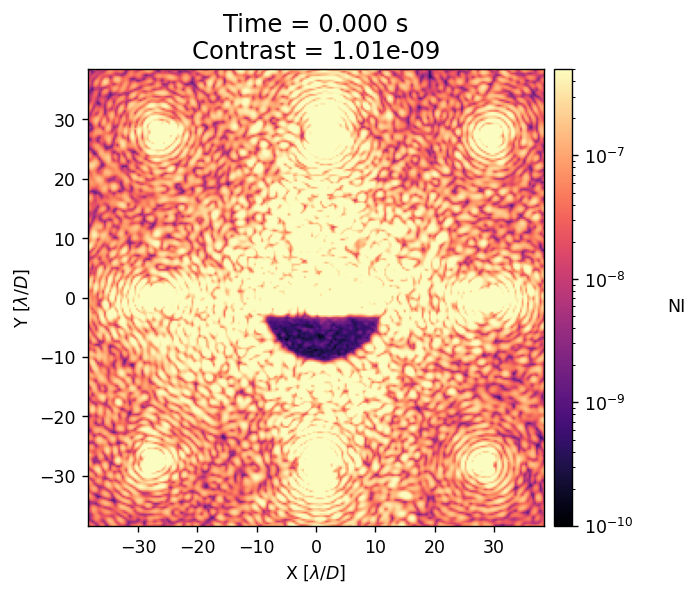

In [132]:
anim = create_time_series_anim(
    all_ims,
    all_contrasts,
    all_times,
    # numframes=5,
    norm=LogNorm(1e-10,5e-7),
    pxscl=1/3.326, 
)

In [133]:
writervideo = FFMpegWriter(fps=5) 
anim.save(f'scoob_time_series.mp4', writer=writervideo)

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:figure size in inches has been adjusted from 5.0 x 5.0 to 4.992 x 4.992
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 624x624 -pix_fmt rgba -framerate 5 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y scoob_time_series.mp4


In [3]:
10**(-17/10) / 10**(-0/10)

0.0199526231496888

In [4]:
10**(-17.5/10) / 10**(-0/10)

0.01778279410038923

In [ ]:
7.4 * 1024 / 3600

2.104888888888889

In [9]:
data_path = Path('/data/users/kianmilani/20260706-atten10')
iefc_data = utils.load_pickle(data_path/'iefc_results_90.pkl')
wfs_mask = iefc_data['wfs_mask']

ts_dirs = [
    'time-series-1',
]

ts_ims = []
ts_times = []
contrasts = []
for i in range(len(ts_dirs)):
    ts_path = data_path/ts_dirs[i]
    ts_fnames = utils.get_fnames(ts_path/'*.fits')

    short_ts_ims = []
    short_ts_contrasts = []
    short_ts_times = []
    for j in range(len(ts_fnames)):
        im = ensure_np_array(utils.load_fits(ts_fnames[j]))
        abs_time = float(ts_fnames[j][-22:-5])
        if i==0 and j==0: t0 = abs_time
        rel_time = abs_time - t0
        short_ts_times.append(rel_time)
        short_ts_ims.append(im)
        short_ts_contrasts.append(ensure_np_array(utils.mean(xp.array(im), wfs_mask)))

        # utils.save_fits(ts_fnames[j]+'.fits', im)

    ts_ims.append(short_ts_ims)
    ts_times.append(short_ts_times)
    contrasts.append(short_ts_contrasts)


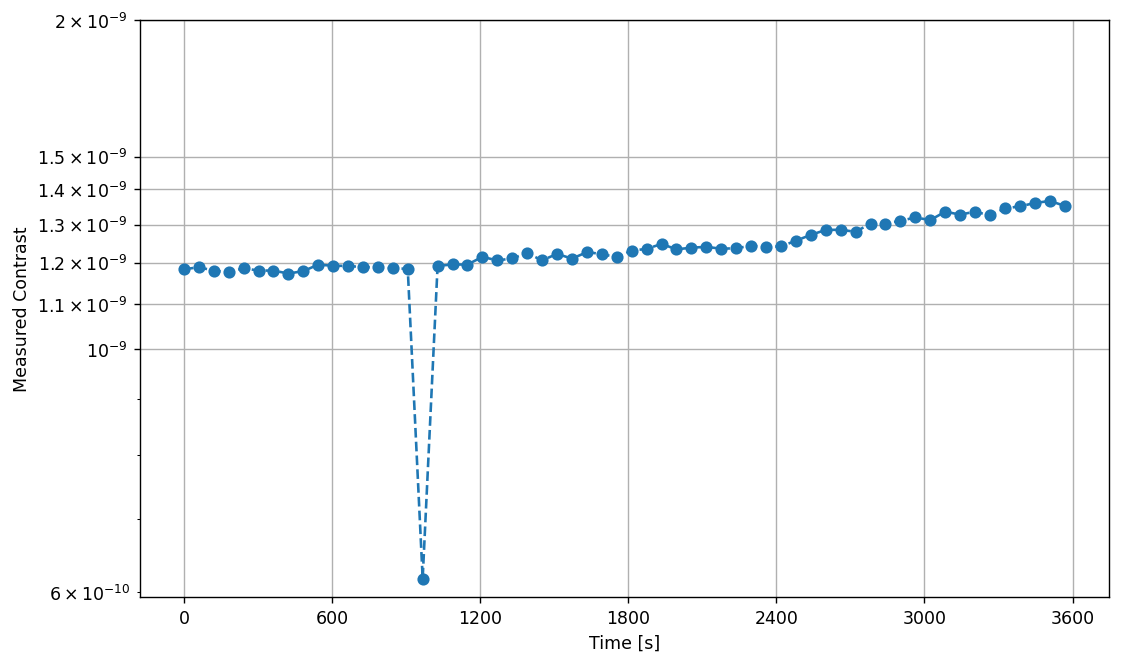

In [ ]:

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(10,6), dpi=125)
for i in range(len(contrasts)):
    axs.semilogy(ts_times[i], contrasts[i], label=f'Dataset {i+1}', marker='o', linestyle='--')

axs.set_xlabel('Time [s]')
axs.set_ylabel('Measured Contrast')
axs.set_xticks(np.arange(0, 4000, 600))
axs.set_yticks([1e-9, 1.1e-9, 1.2e-9, 1.3e-9, 1.4e-9, 1.5e-9, 2e-9])
axs.grid()

array([1.e-09, 1.e-08, 1.e-07])

In [24]:
data_path = Path('/data/users/kianmilani/20260707-atten17')
iefc_data = utils.load_pickle(data_path/'iefc_results_90.pkl')
wfs_mask = iefc_data['wfs_mask']

ts_dirs = [
    'time-series-1',
]

ts_ims = []
ts_times = []
contrasts = []
for i in range(len(ts_dirs)):
    ts_path = data_path/ts_dirs[i]
    ts_fnames = utils.get_fnames(ts_path/'*')

    short_ts_ims = []
    short_ts_contrasts = []
    short_ts_times = []
    for j in range(len(ts_fnames)):
        im = ensure_np_array(utils.load_fits(ts_fnames[j]))
        abs_time = float(ts_fnames[j][-17:])
        # abs_time = float(ts_fnames[j][-22:-5])
        if i==0 and j==0: t0 = abs_time
        rel_time = abs_time - t0
        short_ts_times.append(rel_time)
        short_ts_ims.append(im)
        short_ts_contrasts.append(ensure_np_array(utils.mean(xp.array(im), wfs_mask)))

        # utils.save_fits(ts_fnames[j]+'.fits', im)

    ts_ims.append(short_ts_ims)
    ts_times.append(short_ts_times)
    contrasts.append(short_ts_contrasts)

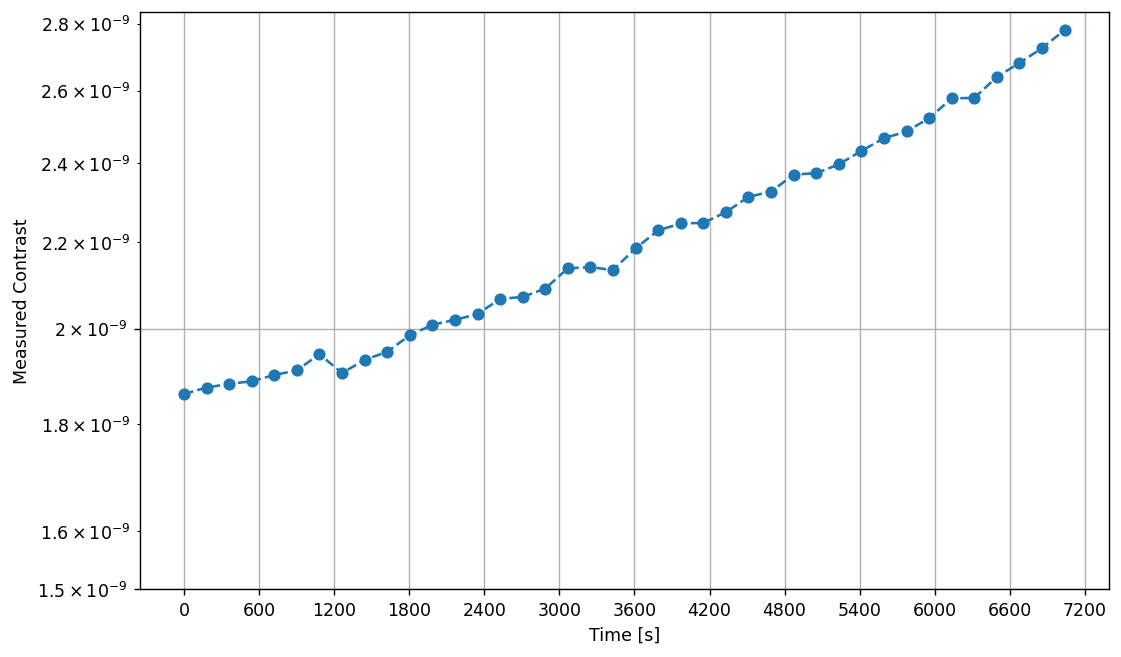

In [29]:

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(10,6), dpi=125)
for i in range(len(contrasts)):
    axs.semilogy(ts_times[i], contrasts[i], label=f'Dataset {i+1}', marker='o', linestyle='--')

axs.set_xlabel('Time [s]')
axs.set_ylabel('Measured Contrast')
axs.set_xticks(np.arange(0, 7500, 600))
axs.set_yticks([1.5e-9, 2e-9])
axs.grid()